In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\data science\\ML\\SUPERVISED LEARNING\\Dataset\\unique_randomforest_dataset.csv')
X = df.drop(columns='crop_stress')
y =  df.crop_stress
df.head(4)

,soil_moisture,temperature,humidity,rainfall,sunlight_hours,soil_ph,fertilizer_used_kg,pest_incidents,irrigation_last_7_days,crop_type,crop_stress
0,36.217808,37.747896,45.545312,28.244709,4.990768,7.444771,18.450887,4,2,rice,0
1,76.550001,15.737607,25.378392,114.175483,4.564285,6.017159,6.775844,5,7,wheat,0
2,61.239576,15.663707,50.722167,37.054071,11.275436,8.117184,25.919981,9,5,cotton,0
3,51.906094,24.708307,43.341312,55.728613,5.521030,7.339349,5.630461,6,6,rice,0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'soil_moisture'),
  Text(1, 0, 'temperature'),
  Text(2, 0, 'humidity'),
  Text(3, 0, 'rainfall'),
  Text(4, 0, 'sunlight_hours'),
  Text(5, 0, 'soil_ph'),
  Text(6, 0, 'fertilizer_used_kg'),
  Text(7, 0, 'pest_incidents'),
  Text(8, 0, 'irrigation_last_7_days'),
  Text(9, 0, 'crop_stress')])

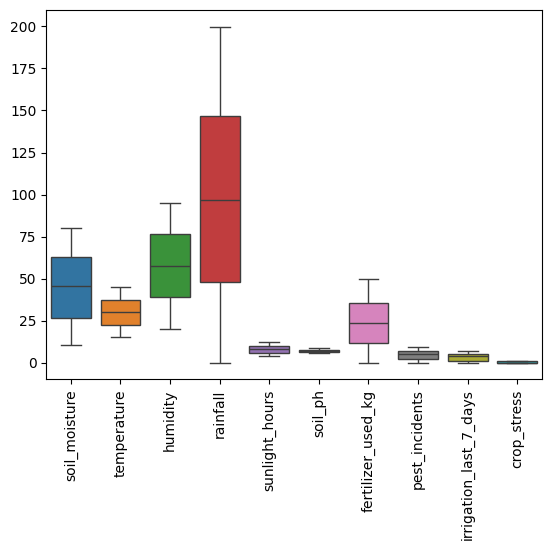

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df)
plt.xticks(rotation=90)

In [9]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y,train_size=0.8,random_state=42)

In [10]:
num_cols = X.select_dtypes(include="number").columns
obj_cols = X.select_dtypes(exclude='number').columns

In [11]:
preprocessing = ColumnTransformer(
    transformers=[
        ('encoder',OneHotEncoder(),obj_cols),
        ('scaling',MinMaxScaler(),num_cols)
    ]
)
main_pipe = Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',RandomForestClassifier())
    ]
)
main_pipe.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [12]:
ytrain_pred = main_pipe.predict(xtrain)

In [13]:
confusion_matrix(ytrain,ytrain_pred)

array([[646,   0],
       [  0, 314]])

In [14]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       646
           1       1.00      1.00      1.00       314

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [15]:
ytest_pred = main_pipe.predict(xtest)
confusion_matrix(ytest,ytest_pred)

array([[155,   0],
       [  1,  84]])

In [16]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       155
           1       1.00      0.99      0.99        85

    accuracy                           1.00       240
   macro avg       1.00      0.99      1.00       240
weighted avg       1.00      1.00      1.00       240

